In [1]:
from IPython.display import Image

## 2. 점연산 

### 0. 학습 목표 

- 명암 보정의 필요성 
- 감마 명암 보정
- 히스토그램 평활화 기법 

### 1.  명암 및 컬러 조정의 필요성 

- 동일한 대상이 조명에 따라 매우 다른 화소값 갖음
    - 조명의 종류 (자연광/형광등/백열등/LED조명,  아침/저녁, 날씨), 조명의 위치 등 
    - 사람은 이러한 조명의 상태를 보상할 수 있는 눈의 특성과 시각 지능이 발전해 있음.
    - 컴퓨터에서도 이러한 보상 기능이 필요함.


### 2. 감마 보정 


- 명암 조정은 이 중에 가장 쉽고, 중요   
    - 화소의 밝기 차이가 충분히 크게 하여 선명하게 함

- 화소값 범위 $[0,L-1]$에서 다음과 같이 화소값을 변경  

    $ f'(y,x) =  (L-1) (f(y,x)/(L-1))^\gamma $      
    
    - $\gamma > 1.0$ Convex 형태의 함수이므로 밝은 부분의 구분이 쉽게됨  
    - $\gamma < 1.0$ Concave 형태의 함수이므로 어두움 부분의 구분이 쉽게됨
    

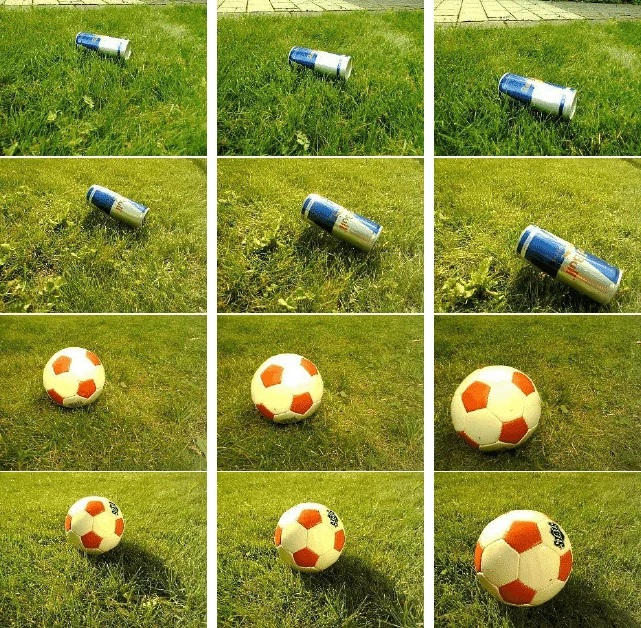

In [2]:
Image("cloudy_sunny.jpg", width=720)

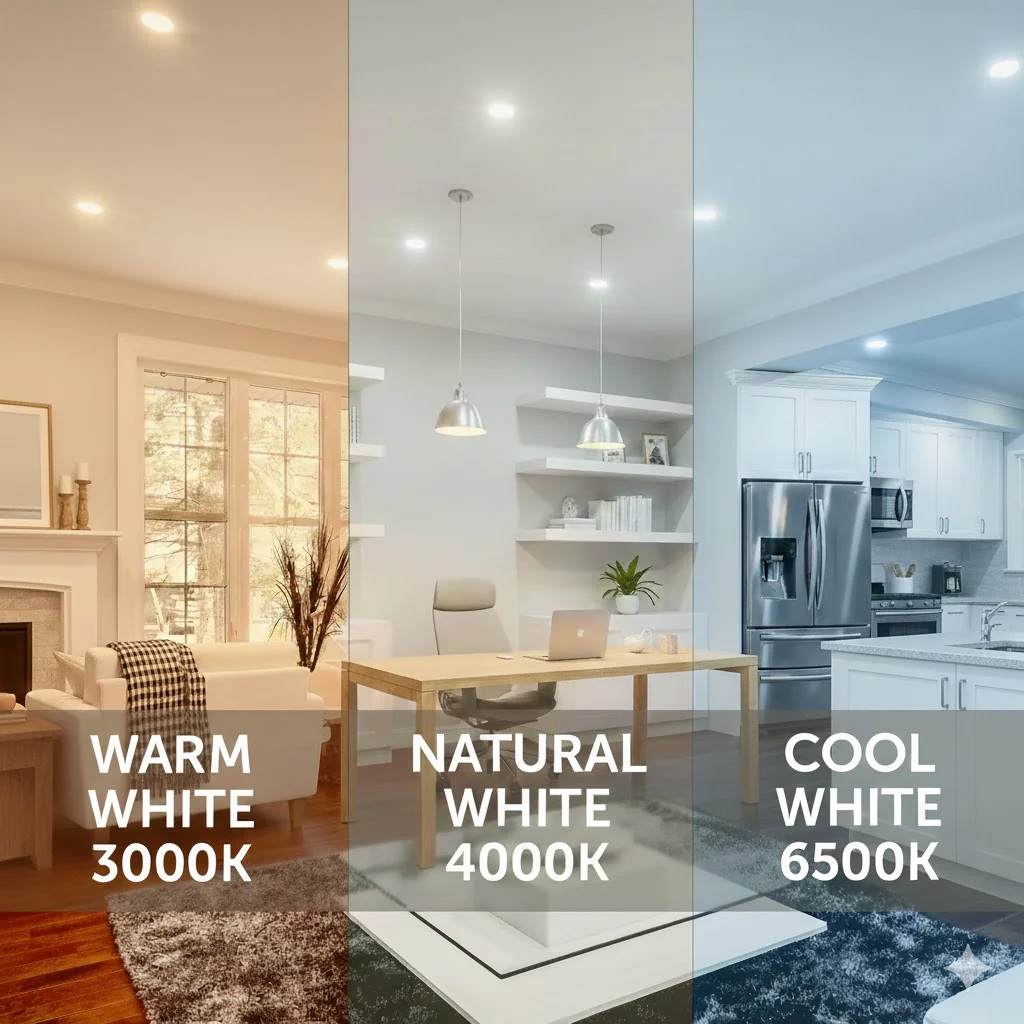

In [3]:
Image("lighttemperatures.jpg", width=720)

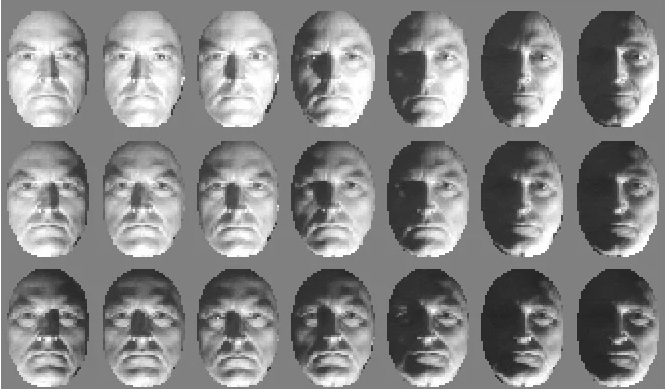

In [4]:
Image("lightdirection.jpg", width=720)

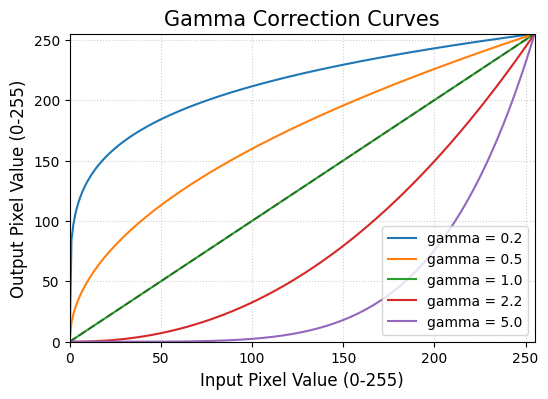

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 입력 값 생성 (0부터 255까지 256개)
x = np.linspace(0, 255, 256)

# 2. 다양한 감마 값 설정
gammas = [0.2, 0.5, 1.0, 2.2, 5.0]

plt.figure(figsize=(6, 4))

for g in gammas:
    # 감마 보정 공식 적용: ((x/255)^gamma) * 255
    # 수업용으로 직관적인 수식을 그대로 사용합니다.
    y = ((x / 255.0) ** g) * 255
    
    # 그래프 그리기
    plt.plot(x, y, label=f'gamma = {g}')

# 3. 그래프 꾸미기 (학생들 이해 돕기)
plt.title('Gamma Correction Curves', fontsize=15)
plt.xlabel('Input Pixel Value (0-255)', fontsize=12)
plt.ylabel('Output Pixel Value (0-255)', fontsize=12)

# 기준점(대각선) 강조 - gamma=1.0일 때
plt.axline((0, 0), (255, 255), color='black', linestyle='--', alpha=0.3)

plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.xlim(0, 255)
plt.ylim(0, 255)
plt.show()

Text(0.5, 1.0, 'Gamma Corrected (gamma=0.5)')

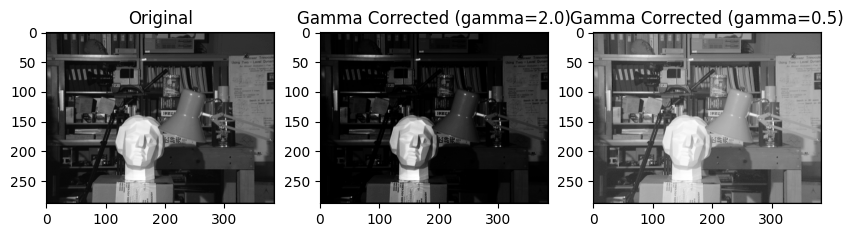

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def GammaConversion(gamma):
    # 3. 감마 보정 공식 적용 (학생들에게 이 단계를 설명해주세요)
    # 공식: Output = ((Input / (L-1) ^ gamma) * (L-1)
    # ① 0~255인 픽셀값을 0~1.0 사이로 만듭니다 (나누기 255)
    # ② 감마 제곱을 합니다 (** gamma)
    # ③ 다시 0~255 범위로 되돌립니다 (곱하기 255)
    out = np.array((L-1) * (img_gray / (L-1)) ** gamma, dtype='uint8')
    return out


# 1. 이미지 읽기
img = cv2.imread('tsukuba_l.png')
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) # 색상 변환

# 2. 감마 값 설정 (1.0보다 크면 밝아지고, 작으면 어두워짐)
L = 256
gamma2_0 = 2.0 
gamma0_5 = 0.5 
img_gamma2_0 = GammaConversion(gamma2_0)
img_gamme0_5 = GammaConversion(gamma0_5)

# 4. 결과 비교 시각화
plt.figure(figsize=(10, 6))
plt.subplot(1, 3, 1); plt.imshow(img_gray, cmap="gray"); plt.title('Original')
plt.subplot(1, 3, 2); plt.imshow(img_gamma2_0, cmap="gray"); plt.title(f'Gamma Corrected (gamma={gamma2_0})')
plt.subplot(1, 3, 3); plt.imshow(img_gamme0_5, cmap="gray"); plt.title(f'Gamma Corrected (gamma={gamma0_5})')


### 2. 히스토그램 평활화  

- Gamma보정의 단점 
   -  변환식이 고정되어 있음
   -  Gamma 값을 사람이 정해줘야 하는 단점

- 히스토그램 평활화는 입력영상의 특성에 따라 신호 구간을 최대한 이용하는 알고리즘 

  $ f'(y,x) = round ((L-1) h_{acc}(f(y,x)) $
  
  여기서 $h_{acc}(l) = \sum_{i<l} h(i)$ 누적 히스토그램 (사실상 누적 확률 분포를 의미) 
  
- **노트**: 왜 누적 histogram을 변환 함수로 사용하는지도 재미있는 문제이고 전년도 교재나 수업에서는 증명을 하였으니 참고 하기 바람.  

#### 1) 히스토그램 평활과 계산 예

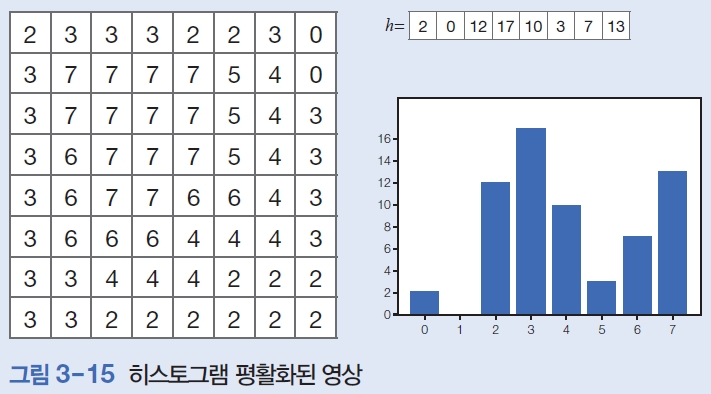

In [7]:
Image("그림 3-15.jpg", width=480)

#### 2) OpenCV 히스토그램 평활화 

- Global  히스토그램 평활화 기법: 이미지 전체에서 히스토그램을 계산하여 적용 
- Adaptive 히스토그램 평활화 기법: 영역을 쪼개고 해당 영영역으 근처 영역에서 히스토그램을 계산하고 이를 적용
    - 이미지의 영역 별로 컨텐츠나 조명의 차이가 생기는 경우 유용한 방법   


(<Axes: title={'center': 'hist_eq'}>,
 Text(0.5, 1.0, 'hist_eq'))

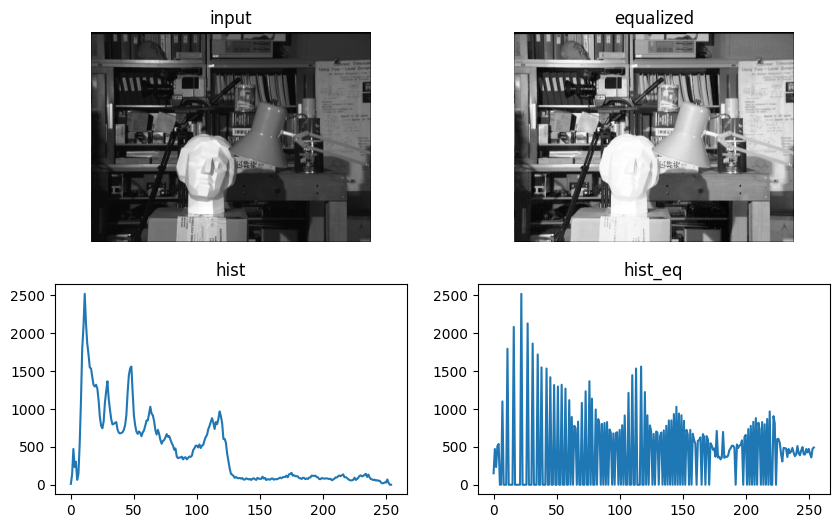

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('tsukuba_l.png', cv2.IMREAD_GRAYSCALE)
assert img is not None, "file could not be read, check with os.path.exists()"
img_eq = cv2.equalizeHist(img) 

# histograms
hist = cv2.calcHist([img],[0],  None, [255], [0,255])
hist_eq = cv2.calcHist([img_eq],[0], None, [255], [0,255])
plt.figure(figsize=(10, 6))
plt.subplot(2,2,1), plt.imshow(img, cmap="gray"), plt.axis('off'), plt.title('input')
plt.subplot(2,2,2), plt.imshow(img_eq, cmap="gray"), plt.axis('off'), plt.title('equalized')
plt.subplot(2,2,3), plt.plot(hist), plt.title('hist')
plt.subplot(2,2,4), plt.plot(hist_eq), plt.title('hist_eq')


#### **노트**
 - 왜 Equlaizer 라고 하는지 알겠나요?
 - 왜 완벽하게 평활화가 안됬냐고?  평활화의 기준은 누적 분표 기준 (한번 누적분포를 직접 계산해 봐요!)이고 입력에 따라 완벽한 평호라화는 불가능. 

### Adaptive Hist Equalizer  

- 간략한 원리 설명 (원리시간상 자세한 설명은 생략)
    - 이미지를 NxN의 영역으로 쪼갠다.
    - 각 영역당 주변의 영역 (자신을 포함 8개)을 포함하여, histogram을 구한 후 현재 영역에 histogram 평활화를 적용 (**적응형!**)
    - 이런한 식으로 NxN 영역에 적용 
    
- 전역 평활화에 비해 결과가 어떤지 관찰
    - 전역 평활화는 전반적으로 어둡거나 밝아야 잘 작동. 시험 영상은 두가지 부분이 석여 있음 => 전역 방법으로 밝은 부분 해결이 안됨
    - 전역 평활화가 더 편안하게 보일 수도 있으나, 미적인 부분이 중요한게 아니라 **정보인식 측면**에서 판단해야함. 
    - 사람의 시각도 이러한 방식으로 작동한다고 함.

(<Axes: title={'center': 'adaptive equalized'}>,
 (-0.5, 383.5, 287.5, -0.5),
 Text(0.5, 1.0, 'adaptive equalized'))

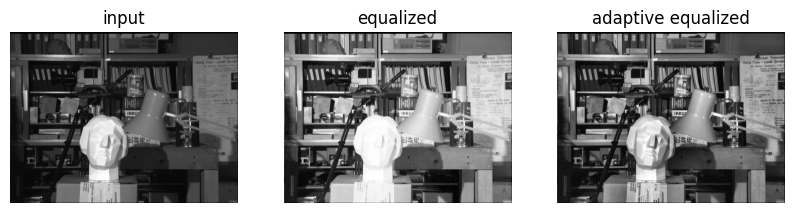

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('tsukuba_l.png',0)
assert img is not None, "file could not be read, check with os.path.exists()"
   
img_eq = cv2.equalizeHist(img)
  
# create a CLAHE object (Arguments are optional).
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
img_cl1 = clahe.apply(img)
plt.figure(figsize=(10, 6)) 
plt.subplot(1,3,1), plt.imshow(img, cmap="gray"), plt.axis('off'), plt.title('input')
plt.subplot(1,3,2), plt.imshow(img_eq, cmap="gray"), plt.axis('off'), plt.title('equalized')
plt.subplot(1,3,3), plt.imshow(img_cl1, cmap="gray"), plt.axis('off'), plt.title('adaptive equalized')

### 끝